<h2 style="color:#0369a1;">📌 Problem Statement</h2>

<p style="color:#1e293b; font-size:16px; line-height:1.8;">
The rapid expansion of e-commerce platforms has resulted in massive volumes of product data, making it increasingly difficult for businesses to optimize pricing strategies, inventory planning, seller performance, and customer satisfaction. Platforms like <strong>Flipkart</strong> host thousands of products across diverse categories, brands, and sellers, where performance is influenced by factors such as pricing, discounts, ratings, reviews, delivery time, and return policies.
</p>

<p style="color:#1e293b; font-size:16px; line-height:1.8;">
This dataset contains <strong>80,000 retail product listings</strong> from Flipkart, offering comprehensive information about products, sellers, pricing structure, customer feedback, logistics, and sales metrics. Extracting meaningful insights from this data requires a structured and data-driven analytical approach.
</p>

<h2 style="color:#0369a1; margin-top:28px;">🎯 Objective</h2>

<p style="color:#1e293b; font-size:16px;">
The main objective of this analysis is to uncover actionable insights that help understand product and seller performance on Flipkart. Specifically, the study aims to:
</p>

<ul style="color:#1e293b; font-size:16px; line-height:1.9;">
<li>Analyze the impact of <strong>pricing, discounts, and final price</strong> on sales volume</li>
<li>Understand how <strong>ratings, reviews, and product scores</strong> influence customer behavior</li>
<li>Evaluate <strong>seller performance</strong> using seller rating, city, and sales data</li>
<li>Identify <strong>category-wise and brand-wise trends</strong></li>
<li>Examine the effect of <strong>delivery time and return policies</strong> on customer satisfaction</li>
</ul>

<h2 style="color:#0369a1; margin-top:28px;">📊 Key Questions</h2>

<ul style="color:#1e293b; font-size:16px; line-height:1.9;">
<li>Which product categories and brands generate the highest sales?</li>
<li>How do discount percentages affect final price and units sold?</li>
<li>Is there a relationship between ratings, review count, and product score?</li>
<li>Do faster delivery times improve ratings and sales performance?</li>
<li>How does seller rating influence product success?</li>
<li>What role do stock availability and return policies play in sales outcomes?</li>
</ul>

<h2 style="color:#0369a1; margin-top:28px;">🔍 Scope of Analysis</h2>

<p style="color:#1e293b; font-size:16px; line-height:1.8;">
This project involves <strong>Exploratory Data Analysis (EDA)</strong>, including univariate, bivariate, and multivariate analysis, supported by visualizations and statistical summaries. The goal is to transform raw e-commerce data into meaningful insights that can assist sellers, analysts, and decision-makers in improving platform performance and customer experience.
</p>

<div style="margin-top:30px; padding:18px; background:#ecfeff; border-left:6px solid #06b6d4; border-radius:10px;">
<p style="margin:0; color:#0f172a; font-size:15px;">
📌 <strong>Outcome:</strong> Data-driven insights to support better pricing strategies, seller optimization, inventory planning, and customer satisfaction in e-commerce ecosystems.
</p>
</div>

</div>



# Step 1: Setup & Data Loading

## 1.1 Import Libraries
Load Python packages for data analysis and visualization.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)

## 1.2 Load Dataset
Read the CSV dataset and preview the first rows.

In [12]:
df = pd.read_csv(r"C:\Users\chitt\VS Code Projects\Flipkart Retail Product Analysis\flipkard.csv")
df.head()

,product_id,product_name,category,brand,seller,seller_city,price,discount_percent,final_price,rating,review_count,stock_available,units_sold,listing_date,delivery_days,weight_g,warranty_months,color,size,return_policy_days,is_returnable,payment_modes,shipping_weight_g,product_score,seller_rating
0,FKP0000001,Adidas Ultra 664,Toys,Adidas,MegaStore,Hyderabad,35547.34,15,30215.24,1.9,26975,267,66,2022-04-12,11,3038.23,36,Green,XL,30,True,"COD,CARD",3483.592454,6.78,3.28
1,FKP0000002,LG Series 124,Fashion,LG,ValueKart,Mumbai,30693.79,10,27624.41,3.2,45848,16,2703,2023-05-14,3,1921.82,0,Grey,One Size,7,True,"UPI,CARD",2091.473835,50.78,3.42
2,FKP0000003,Redmi Model 35,Beauty,Redmi,SmartDeals,Ahmedabad,51214.50,40,30728.70,4.4,5138,806,2394,2022-09-13,5,1143.49,12,Black,M,0,False,"COD,UPI,CARD",1242.770494,4.24,4.23
3,FKP0000004,Sony Edition 769,Toys,Sony,UrbanRetails,Delhi,33168.49,30,23217.94,2.8,2000,509,1732,2019-08-05,1,3644.81,24,Black,L,0,False,"CARD,Wallet",3891.222716,1.38,3.45
4,FKP0000005,Boat Prime 291,Home & Kitchen,Boat,RetailHub,Pune,14181.34,0,14181.34,3.7,25801,809,4644,2018-08-26,7,310.33,0,Blue,NaN,30,True,"CARD,Wallet",386.061014,79.27,4.90


## 1.3 Initial Data Inspection
Check column names, data types, and sample values.

In [15]:
# View column names, non-null counts, and data types
df.info()

# See a random sample of 5 rows
print(df.sample(5))

# Get the exact dimensions (rows, columns)
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_id          80000 non-null  object 
 1   product_name        80000 non-null  object 
 2   category            80000 non-null  object 
 3   brand               80000 non-null  object 
 4   seller              80000 non-null  object 
 5   seller_city         80000 non-null  object 
 6   price               80000 non-null  float64
 7   discount_percent    80000 non-null  int64  
 8   final_price         80000 non-null  float64
 9   rating              80000 non-null  float64
 10  review_count        80000 non-null  int64  
 11  stock_available     80000 non-null  int64  
 12  units_sold          80000 non-null  int64  
 13  listing_date        80000 non-null  object 
 14  delivery_days       80000 non-null  int64  
 15  weight_g            80000 non-null  float64
 16  warr

(80000, 25)

# Step 2: Data Exploration

## 2.1 Check Null Values
Identify missing values in the dataset.

In [19]:
# Count missing values per column
df.isnull().sum()

product_id                0
product_name              0
category                  0
brand                     0
seller                    0
seller_city               0
price                     0
discount_percent          0
final_price               0
rating                    0
review_count              0
stock_available           0
units_sold                0
listing_date              0
delivery_days             0
weight_g                  0
warranty_months           0
color                     0
size                  13484
return_policy_days        0
is_returnable             0
payment_modes             0
shipping_weight_g         0
product_score             0
seller_rating             0
dtype: int64

## 2.2 Check Duplicates
Ensure no repeated freelancer entries exist.

In [22]:
# Count total duplicate rows
df.duplicated().sum()

0

## 2.3 Summary Statistics
Get basic statistics for numerical columns.

In [25]:
# Statistics for numerical columns
df.describe()

,price,discount_percent,final_price,rating,review_count,stock_available,units_sold,delivery_days,weight_g,warranty_months,return_policy_days,shipping_weight_g,product_score,seller_rating
count,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.00000,80000.000000,80000.000000,80000.000000,80000.000000
mean,30137.256454,21.350625,23697.780600,2.999671,25102.249875,499.194262,2507.515775,6.006325,2522.224622,15.56400,12.362250,2899.960047,50.673750,4.002218
std,17274.048682,16.354446,14726.821259,1.156238,14428.769942,288.917706,1439.519972,3.160630,1428.287966,12.91307,10.019794,1650.921766,28.562732,0.577595
min,200.140000,0.000000,101.080000,1.000000,0.000000,0.000000,0.000000,1.000000,50.020000,0.00000,0.000000,53.155250,1.000000,3.000000
25%,15180.205000,10.000000,11341.722500,2.000000,12605.000000,249.000000,1261.000000,3.000000,1283.117500,6.00000,7.000000,1469.583781,25.950000,3.500000
50%,30164.455000,20.000000,22571.265000,3.000000,25166.500000,499.000000,2513.000000,6.000000,2524.550000,12.00000,10.000000,2892.632502,50.670000,4.010000
75%,45077.087500,40.000000,34521.057500,4.000000,37666.000000,749.000000,3754.000000,9.000000,3753.195000,24.00000,15.000000,4304.695597,75.430000,4.500000
max,59995.800000,50.000000,59995.800000,5.000000,49999.000000,999.000000,4999.000000,11.000000,4999.920000,36.00000,30.000000,6234.757448,100.000000,5.000000


In [27]:
# Statistics for categorical (text) columns
df.describe(include='O')

,product_id,product_name,category,brand,seller,seller_city,listing_date,color,size,payment_modes
count,80000,80000,80000,80000,80000,80000,80000,80000,66516,80000
unique,80000,48801,8,15,8,8,2001,8,5,4
top,FKP0000001,Adidas Series 497,Toys,Puma,ValueKart,Pune,2018-12-21,Silver,L,"CARD,Wallet"
freq,1,7,10151,5409,10109,10138,61,10101,13450,20114


# Step 3: Data Cleaning & Preprocessing
## 3.1 Validate Data Types
Confirm numerical and categorical columns are correctly formatted.

In [30]:
df.dtypes

product_id             object
product_name           object
category               object
brand                  object
seller                 object
seller_city            object
price                 float64
discount_percent        int64
final_price           float64
rating                float64
review_count            int64
stock_available         int64
units_sold              int64
listing_date           object
delivery_days           int64
weight_g              float64
warranty_months         int64
color                  object
size                   object
return_policy_days      int64
is_returnable            bool
payment_modes          object
shipping_weight_g     float64
product_score         float64
seller_rating         float64
dtype: object

## 3.2 Impute missing values
Impute the missing values of `size` with mode

In [33]:
size_mode_per_category = df.groupby('category')['size'].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else 'One Size')

# Function to fill missing size
def fill_size(row):
    if pd.isna(row['size']):
        return size_mode_per_category.get(row['category'], 'One Size')
    return row['size']

# Apply function
df['size'] = df.apply(fill_size, axis=1)

# Verify
print("Missing 'size' values after imputation:", df['size'].isna().sum())

Missing 'size' values after imputation: 0


<ul style="color:#1e293b; font-size:16px; line-height:1.9;">
<li>Which product categories and brands generate the highest sales?</li>
<li>How do discount percentages affect final price and units sold?</li>
<li>Is there a relationship between ratings, review count, and product score?</li>
<li>Do faster delivery times improve ratings and sales performance?</li>
<li>How does seller rating influence product success?</li>
<li>What role do stock availability and return policies play in sales outcomes?</li>
</ul>

# 📊 Key Questions
## Q1. Which product categories and brands generate the highest sales?

Top categories by units sold:
 category
Toys              25565969
Electronics       25372487
Appliances        25184186
Fashion           25182630
Beauty            25129312
Sports            24792347
Mobiles           24710378
Home & Kitchen    24663953
Name: units_sold, dtype: int64


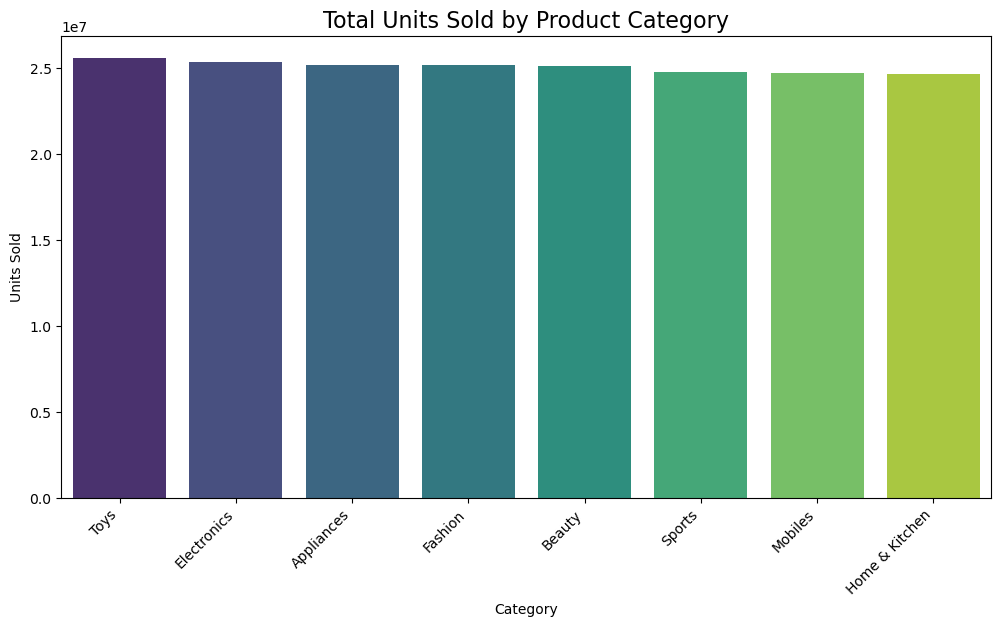

In [37]:
# Ensure 'units_sold' is numeric
df['units_sold'] = pd.to_numeric(df['units_sold'], errors='coerce')

# 1️⃣ Category-wise total units sold
category_sales = df.groupby('category')['units_sold'].sum().sort_values(ascending=False)

# Display top categories
print("Top categories by units sold:\n", category_sales.head(10))

# Plot category-wise sales
plt.figure(figsize=(12,6))
sns.barplot(x=category_sales.index, y=category_sales.values, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Total Units Sold by Product Category', fontsize=16)
plt.xlabel('Category')
plt.ylabel('Units Sold')
plt.show()

Top brands by units sold:
 brand
Nike        13569204
Reebok      13507145
Prestige    13497983
Adidas      13459726
Puma        13443146
Apple       13425297
Dell        13415026
LG          13403447
HP          13356680
Redmi       13320362
Name: units_sold, dtype: int64


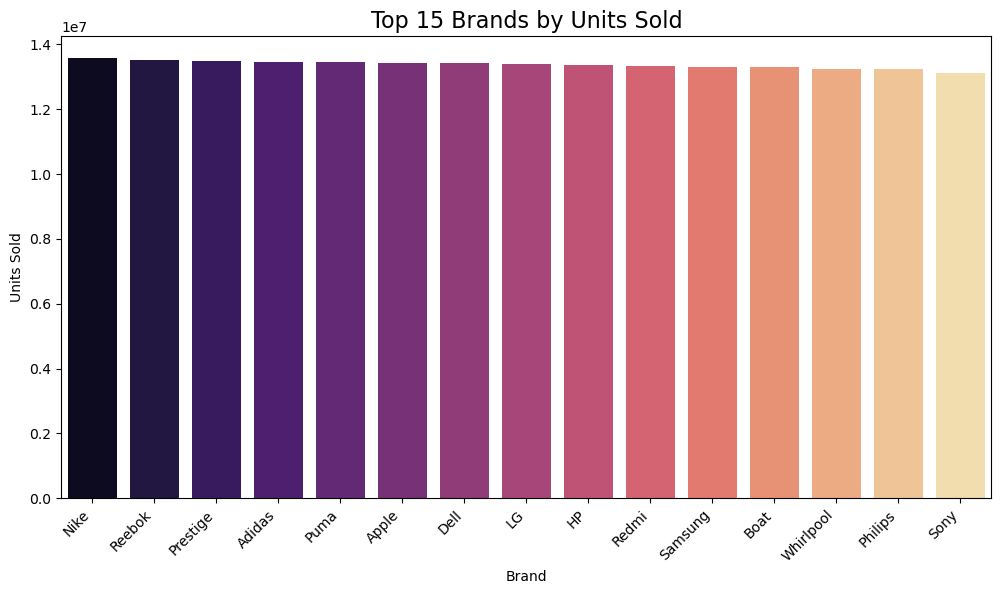

In [39]:
# 2️⃣ Brand-wise total units sold
brand_sales = df.groupby('brand')['units_sold'].sum().sort_values(ascending=False)

# Display top brands
print("Top brands by units sold:\n", brand_sales.head(10))

# Plot brand-wise sales
plt.figure(figsize=(12,6))
sns.barplot(x=brand_sales.head(15).index, y=brand_sales.head(15).values, palette='magma')
plt.xticks(rotation=45, ha='right')
plt.title('Top 15 Brands by Units Sold', fontsize=16)
plt.xlabel('Brand')
plt.ylabel('Units Sold')
plt.show()


## Q2: How do discount percentages affect final price and units sold?

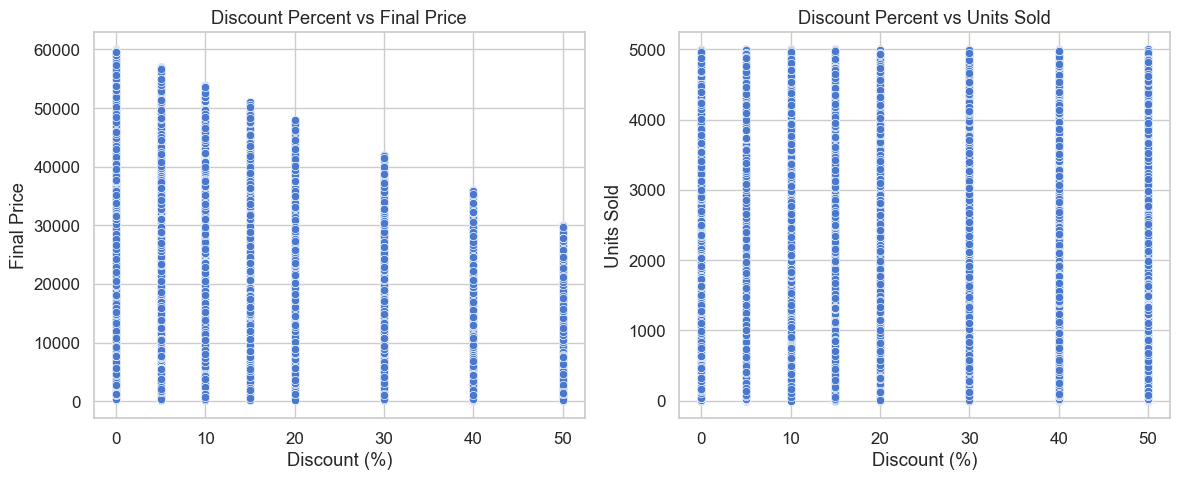

   discount_percent   final_price
0                 0  30123.754495
1                 5  28410.499956
2                10  27122.621494
3                15  25691.275048
4                20  24276.805134


In [42]:
# Ensure numeric columns are numeric
numeric_cols = [
    'price', 'discount_percent', 'final_price', 'units_sold',
    'rating', 'review_count', 'product_score',
    'delivery_days', 'seller_rating', 'stock_available'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Set Seaborn style
sns.set(style='whitegrid', palette='muted', font_scale=1.1)

# --- Q2: How do discount percentages affect final price and units sold? ---
plt.figure(figsize=(12, 5))

# Scatter: Discount vs Final Price
plt.subplot(1, 2, 1)
sns.scatterplot(
    x='discount_percent',
    y='final_price',
    data=df
)
plt.title('Discount Percent vs Final Price')
plt.xlabel('Discount (%)')
plt.ylabel('Final Price')


plt.subplot(1,2,2)
sns.scatterplot(x='discount_percent', y='units_sold', data=df)
plt.title('Discount Percent vs Units Sold')
plt.xlabel('Discount (%)')
plt.ylabel('Units Sold')
plt.tight_layout()
plt.show()


# Grouped analysis (Average Final Price by Discount)
discount_price = (
    df.groupby('discount_percent', as_index=False)['final_price']
      .mean()
      .sort_values(by='discount_percent')
)

print(discount_price.head())

plt.show()



## Q3: Is there a relationship between ratings, review count, and product score?

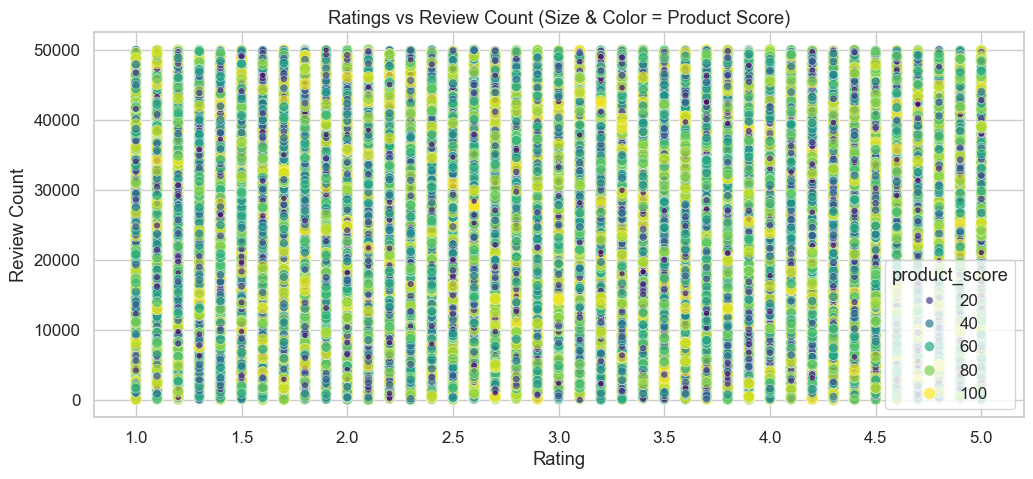

In [45]:
# --- ---
plt.figure(figsize=(12,5))
sns.scatterplot(x='rating', y='review_count', size='product_score', hue='product_score', data=df, alpha=0.7, palette='viridis')
plt.title('Ratings vs Review Count (Size & Color = Product Score)')
plt.xlabel('Rating')
plt.ylabel('Review Count')
plt.show()

## Q4. Do faster delivery times improve ratings and sales performance?


Text(0, 0.5, 'Rating')

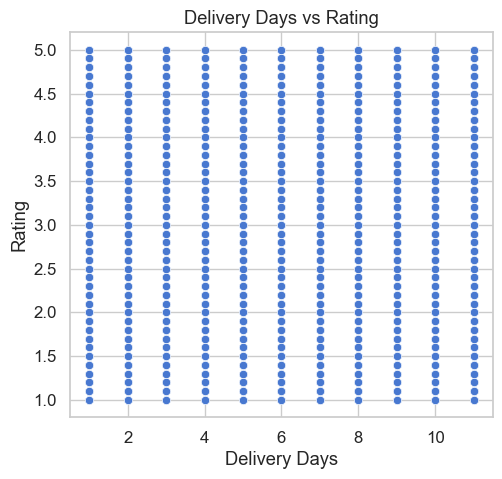

In [48]:
# --- Q4: Do faster delivery times improve ratings and sales? ---
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.scatterplot(x='delivery_days', y='rating', data=df)
plt.title('Delivery Days vs Rating')
plt.xlabel('Delivery Days')
plt.ylabel('Rating')

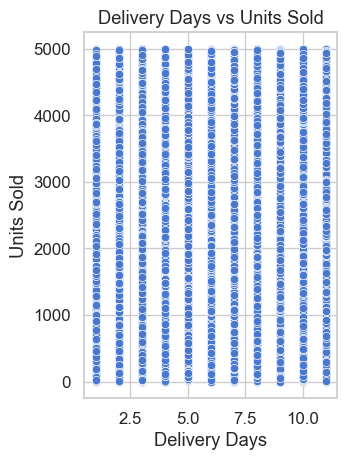

In [50]:
plt.subplot(1,2,2)
sns.scatterplot(x='delivery_days', y='units_sold', data=df)
plt.title('Delivery Days vs Units Sold')
plt.xlabel('Delivery Days')
plt.ylabel('Units Sold')
plt.tight_layout()
plt.show()

## Q5. How does seller rating influence product success?


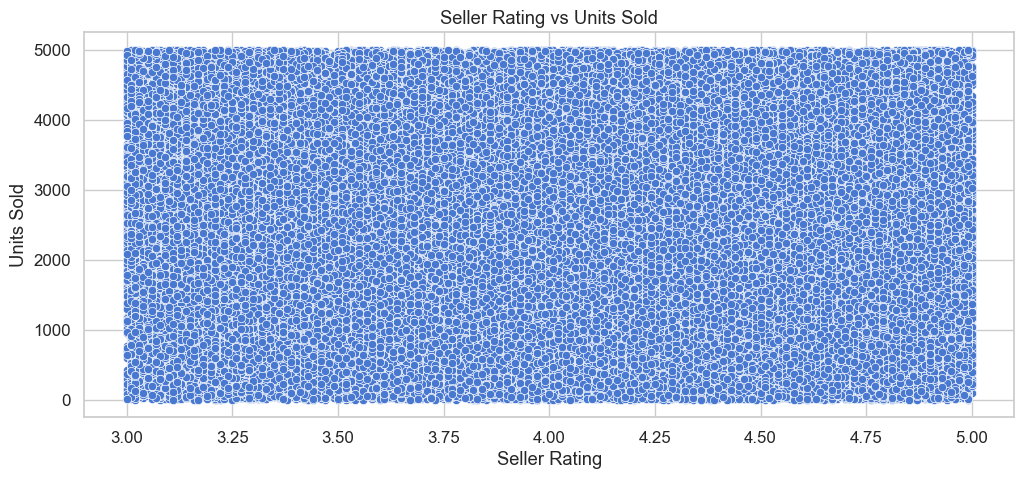

In [53]:

# --- Q5: How does seller rating influence product success? ---
plt.figure(figsize=(12,5))
sns.scatterplot(x='seller_rating', y='units_sold', data=df)
plt.title('Seller Rating vs Units Sold')
plt.xlabel('Seller Rating')
plt.ylabel('Units Sold')
plt.show()

In [57]:
# -------------------------------
# Seaborn styling
# -------------------------------
sns.set(style='whitegrid', palette='muted', font_scale=1.1)

Text(0, 0.5, 'Units Sold')

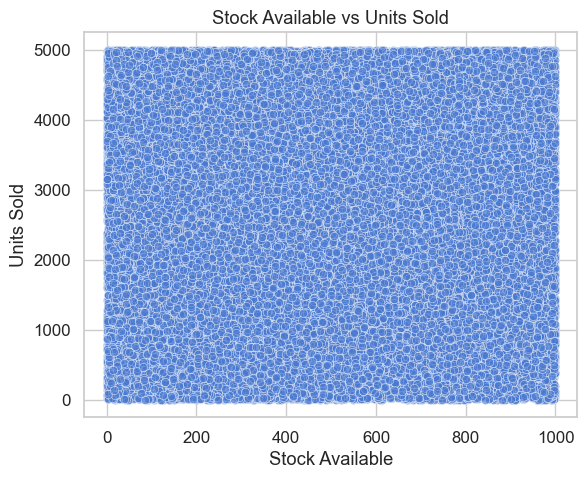

In [59]:
# ===============================
# 🔹 PART 1: VISUAL ANALYSIS
# ===============================
plt.figure(figsize=(14, 5))

# Stock Available vs Units Sold
plt.subplot(1, 2, 1)
sns.scatterplot(
    data=df,
    x='stock_available',
    y='units_sold',
    alpha=0.6
)
plt.title('Stock Available vs Units Sold')
plt.xlabel('Stock Available')
plt.ylabel('Units Sold')

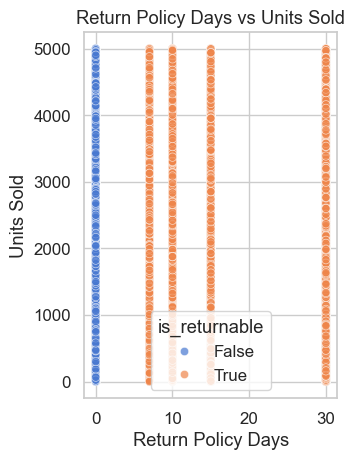

In [61]:
# Return Policy Days vs Units Sold
plt.subplot(1, 2, 2)
sns.scatterplot(
    data=df,
    x='return_policy_days',
    y='units_sold',
    hue='is_returnable',
    alpha=0.7
)
plt.title('Return Policy Days vs Units Sold')
plt.xlabel('Return Policy Days')
plt.ylabel('Units Sold')

plt.tight_layout()
plt.show()

In [63]:
# ===============================
# 🔹 PART 2: NUMERIC ANALYSIS
# ===============================

# -------------------------------
# 1. Correlation Analysis
# -------------------------------
print("📊 Correlation Matrix:")
print(
    df[['stock_available', 'return_policy_days', 'units_sold']]
    .corr()
)
print("\n")

📊 Correlation Matrix:
                    stock_available  return_policy_days  units_sold
stock_available            1.000000           -0.005026   -0.006276
return_policy_days        -0.005026            1.000000   -0.003865
units_sold                -0.006276           -0.003865    1.000000




In [65]:
# 2. Stock Availability Trend (Binned)
# -------------------------------
df['stock_bin'] = pd.qcut(df['stock_available'], q=4, duplicates='drop')

stock_trend = (
    df.groupby('stock_bin', as_index=False)['units_sold']
      .agg(
          avg_units_sold='mean',
          median_units_sold='median',
          total_units_sold='sum',
          count='count'
      )
)

print("📦 Stock Availability vs Units Sold (Binned):")
print(stock_trend)
print("\n")


📦 Stock Availability vs Units Sold (Binned):
         stock_bin  avg_units_sold  median_units_sold  total_units_sold  count
0  (-0.001, 249.0]     2525.916729             2526.0          50536016  20007
1   (249.0, 499.0]     2502.377828             2519.5          50222723  20070
2   (499.0, 749.0]     2496.511035             2495.0          49882787  19981
3   (749.0, 999.0]     2505.252031             2513.0          49959736  19942




In [67]:
# 3. Returnable vs Non-Returnable
# -------------------------------
returnable_analysis = (
    df.groupby('is_returnable')['units_sold']
      .agg(
          avg_units_sold='mean',
          median_units_sold='median',
          total_units_sold='sum',
          count='count'
      )
)

print("🔁 Returnable vs Non-Returnable Products:")
print(returnable_analysis)
print("\n")


🔁 Returnable vs Non-Returnable Products:
               avg_units_sold  median_units_sold  total_units_sold  count
is_returnable                                                            
False             2502.685895             2493.0          39957883  15966
True              2508.720039             2518.5         160643379  64034




In [69]:
# 4. Return Policy Days Trend
# -------------------------------
return_days_trend = (
    df.groupby('return_policy_days', as_index=False)['units_sold']
      .mean()
      .sort_values('return_policy_days')
)

print("📅 Return Policy Days vs Average Units Sold:")
print(return_days_trend.head(10))
print("\n")


📅 Return Policy Days vs Average Units Sold:
   return_policy_days   units_sold
0                   0  2502.685895
1                   7  2500.186733
2                  10  2532.106253
3                  15  2514.234276
4                  30  2488.179832




In [71]:
# 5. Combined Effect (Most Insightful)
# -------------------------------
combined_effect = (
    df.groupby(
        ['is_returnable', 'stock_bin'],
        as_index=False
    )['units_sold']
    .mean()
)

print("📌 Combined Effect: Return Policy + Stock Availability:")
print(combined_effect)


📌 Combined Effect: Return Policy + Stock Availability:
   is_returnable        stock_bin   units_sold
0          False  (-0.001, 249.0]  2511.516436
1          False   (249.0, 499.0]  2452.584281
2          False   (499.0, 749.0]  2524.883882
3          False   (749.0, 999.0]  2520.892051
4           True  (-0.001, 249.0]  2529.396822
5           True   (249.0, 499.0]  2514.606032
6           True   (499.0, 749.0]  2489.322607
7           True   (749.0, 999.0]  2501.234085


## 📊 Overall Business Takeaway

Sales performance is not heavily dependent on stock quantity or return duration alone. While returnable products show slightly better outcomes, companies should focus more on pricing strategy, discounts, ratings, and brand trust to drive meaningful sales growth.